# Notebook 09 — Crack Spread Mediation: Who Captures the Asymmetry Premium?
**Project:** Rising Fast, Falling Slow: The Hidden Cost of Gasoline Price Asymmetry  
**Author:** Kien Nguyen, Hoa Ly

---
## Core Question
The rockets-and-feathers asymmetry is confirmed. But *where* in the supply chain does it live?

```
CRUDE OIL → [Stage 1: Refinery] → CRACK SPREAD → [Stage 2: Retail] → PUMP PRICE
```

- **Stage 1 asymmetry** → Refiners capture value during crude price spikes (widen margins fast, narrow slowly)
- **Stage 2 asymmetry** → Retailers capture value (pass spot increases fast, pass decreases slowly)
- **Both** → Structural problem across the entire supply chain

This has direct policy implications: regulate refiners, retailers, or both?

---
## What This Notebook Does
1. **Margin decomposition** — How the pump price splits across crude, refiner, and retailer
2. **26-year crack spread history** — Crisis overlays, trend, and seasonality
3. **Stage 1 asymmetry** — Crude → Crack Spread (refiner behavior)
4. **Stage 2 asymmetry** — Spot Gas → Retail (retailer behavior)
5. **Decomposition** — Which stage explains more of total asymmetry?
6. **Crisis-specific analysis** — Who captures more during supply vs demand shocks?
7. **Regional crack spread** — Gulf Coast vs New York Harbor spot markets
8. **Poster-ready visualizations**

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from scipy import stats

# Poster palette
NAVY   = '#1B3A5C'
RED    = '#C0392B'
GREEN  = '#1A6B3C'
GOLD   = '#D4A017'
ORANGE = '#E67E22'
PURPLE = '#6C3483'
LGRAY  = '#F0F3F7'
MGRAY  = '#B0B8C1'
DGRAY  = '#5D6D7E'

plt.rcParams.update({
    'font.family'       : 'serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.facecolor'    : LGRAY,
    'figure.facecolor'  : 'white',
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
})

print('Imports complete')

Imports complete


## 1. Load Data & Engineer Margin Variables

In [2]:
df = pd.read_csv('data/processed/master_dataset.csv', parse_dates=['period'])
df = df.sort_values('period').reset_index(drop=True)

# ── Two-stage margin decomposition ───────────────────────────────────────────
# Stage 1 margin: Refiner margin = spot_gasoline - crude_per_gallon
#                 This is already in dataset as crack_spread
# Stage 2 margin: Retailer margin = retail_national - spot_gasoline
df['retailer_margin'] = df['retail_national'] - df['spot_gasoline']

# Verify crack spread formula
assert np.allclose(df['crack_spread'], df['spot_gasoline'] - df['crude_per_gallon'], atol=0.001), \
    'crack_spread formula mismatch'

# ── Week-over-week changes for asymmetry regressions ─────────────────────────
df['crack_spread_chg']    = df['crack_spread'].diff()
df['retailer_margin_chg'] = df['retailer_margin'].diff()

# Already in dataset: wti_crude_chg, spot_gasoline_chg, retail_national_chg

# ── Crisis event windows ──────────────────────────────────────────────────────
CRISES = {
    'Katrina\n2005'    : ('2005-08-01', '2005-12-31', RED),
    'Financial\n2008'  : ('2008-06-01', '2009-06-30', NAVY),
    'COVID\n2020'      : ('2020-01-01', '2020-12-31', PURPLE),
    'Ukraine\n2022'    : ('2022-02-01', '2022-09-30', ORANGE),
}

print(f'Dataset: {len(df)} weeks, {df.period.iloc[0].date()} to {df.period.iloc[-1].date()}')
print(f'\nPump Price Decomposition (26-year average):')
print(f'  Crude cost        : ${df.crude_per_gallon.mean():.4f}/gal  ({df.crude_per_gallon.mean()/df.retail_national.mean()*100:.1f}%)')
print(f'  Refiner margin    : ${df.crack_spread.mean():.4f}/gal  ({df.crack_spread.mean()/df.retail_national.mean()*100:.1f}%)')
print(f'  Retailer margin   : ${df.retailer_margin.mean():.4f}/gal  ({df.retailer_margin.mean()/df.retail_national.mean()*100:.1f}%)')
print(f'  ─────────────────────────────────────────')
print(f'  Total pump price  : ${df.retail_national.mean():.4f}/gal  (100%)')
print(f'\nKey insight: Retailer margin (${df.retailer_margin.mean():.4f}) is {df.retailer_margin.mean()/df.crack_spread.mean():.1f}x the refiner margin (${df.crack_spread.mean():.4f})')

Dataset: 1370 weeks, 2000-01-03 to 2026-03-30

Pump Price Decomposition (26-year average):
  Crude cost        : $1.5186/gal  (55.5%)
  Refiner margin    : $0.3624/gal  (13.3%)
  Retailer margin   : $0.8537/gal  (31.2%)
  ─────────────────────────────────────────
  Total pump price  : $2.7347/gal  (100%)

Key insight: Retailer margin ($0.8537) is 2.4x the refiner margin ($0.3624)


## 2. Part A — 26-Year Margin History & Crisis Analysis

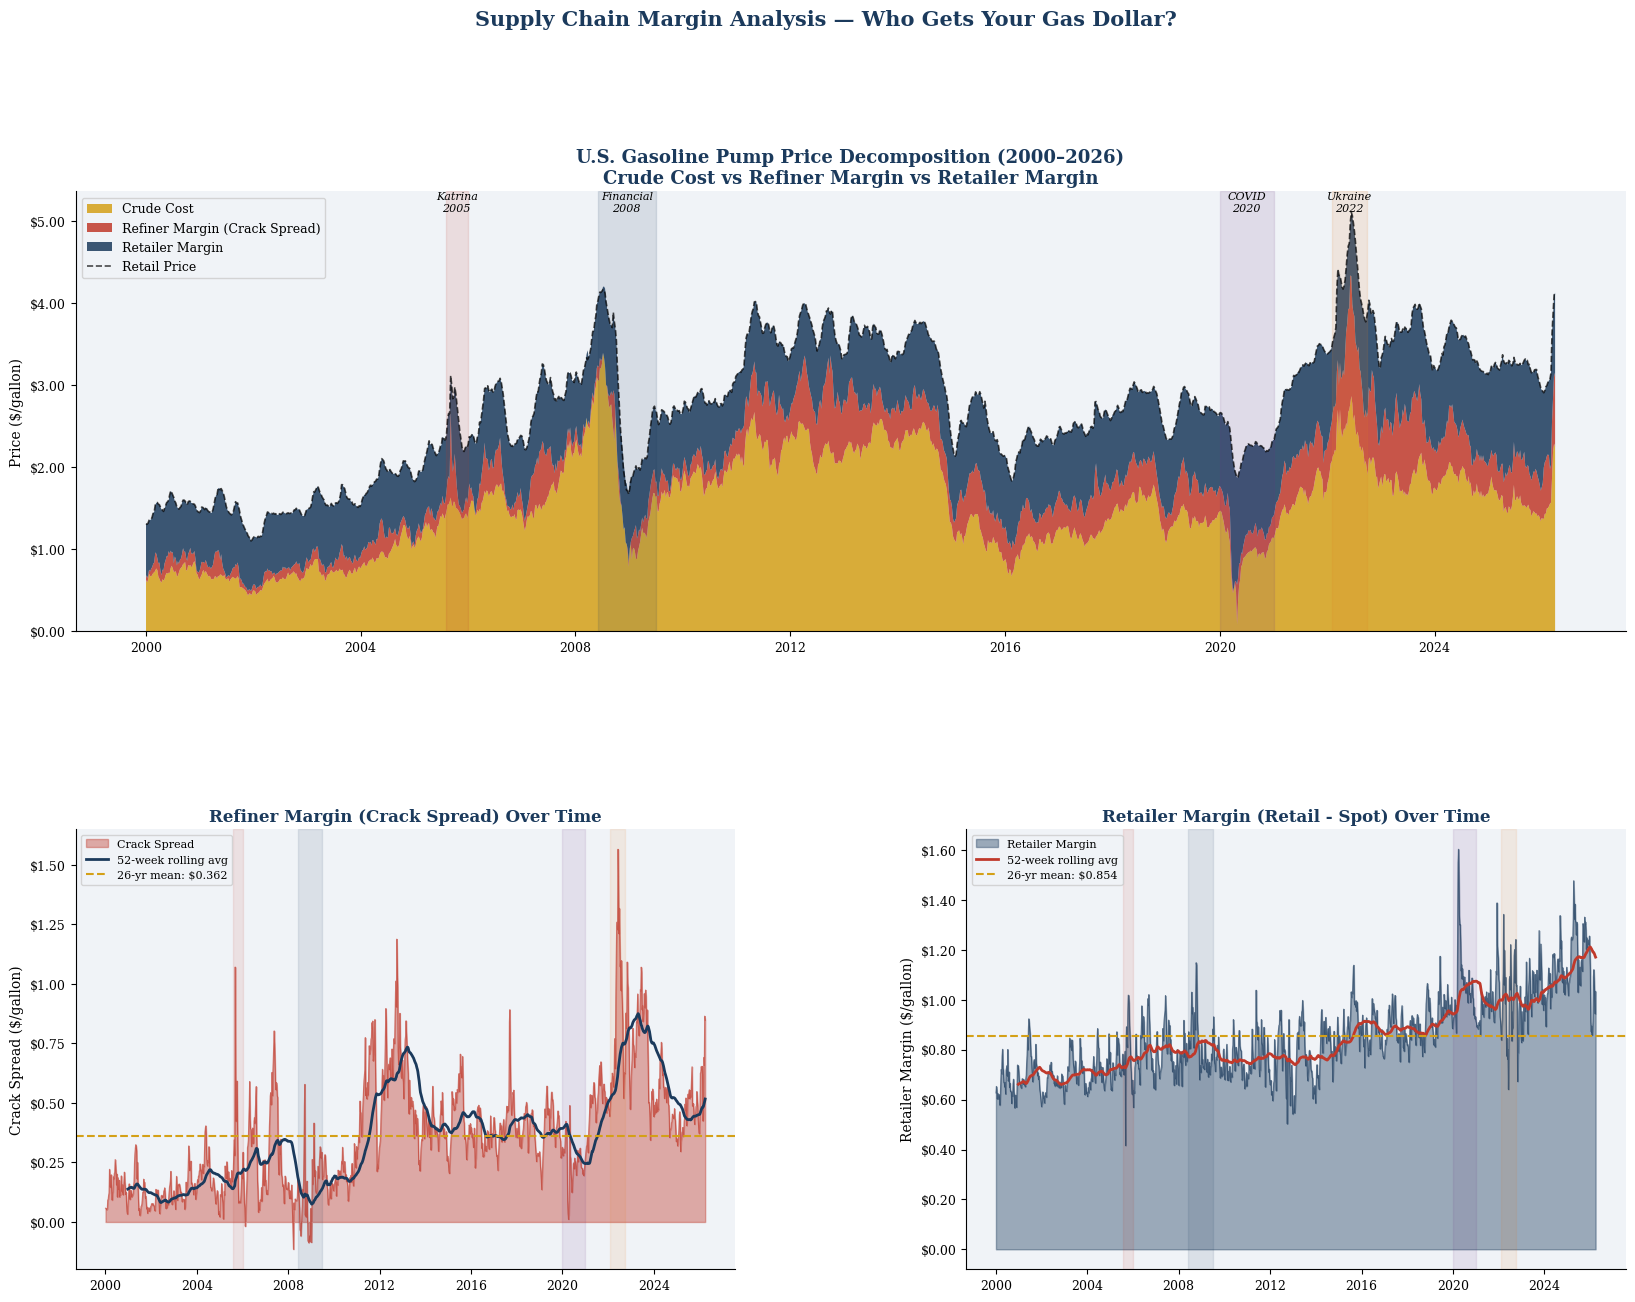

Saved: outputs/crack_margin_history.png


In [3]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# --- Chart 1: Full stacked margin history ---
ax1 = fig.add_subplot(gs[0, :])
ax1.stackplot(
    df['period'],
    df['crude_per_gallon'],
    df['crack_spread'].clip(lower=0),
    df['retailer_margin'].clip(lower=0),
    labels=['Crude Cost', 'Refiner Margin (Crack Spread)', 'Retailer Margin'],
    colors=[GOLD, RED, NAVY],
    alpha=0.85
)
ax1.plot(df['period'], df['retail_national'],
         color='black', lw=1.2, ls='--', label='Retail Price', alpha=0.7)

# Shade crisis periods
for name, (start, end, color) in CRISES.items():
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                alpha=0.12, color=color)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start))/2
    ax1.text(mid, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 1 else 5.5,
             name, ha='center', va='top', fontsize=8, color='black', style='italic')

ax1.set_title('U.S. Gasoline Pump Price Decomposition (2000–2026)\nCrude Cost vs Refiner Margin vs Retailer Margin',
              fontweight='bold', color=NAVY, fontsize=13)
ax1.set_ylabel('Price ($/gallon)')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_facecolor(LGRAY)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))

# --- Chart 2: Crack spread alone with rolling avg ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.fill_between(df['period'], df['crack_spread'], alpha=0.40, color=RED, label='Crack Spread')
ax2.plot(df['period'], df['crack_spread'], color=RED, lw=0.8, alpha=0.6)
ax2.plot(df['period'], df['crack_spread'].rolling(52).mean(),
         color=NAVY, lw=2.0, label='52-week rolling avg')
ax2.axhline(df['crack_spread'].mean(), color=GOLD, lw=1.5, ls='--',
            label=f'26-yr mean: ${df["crack_spread"].mean():.3f}')

for name, (start, end, color) in CRISES.items():
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.10, color=color)

ax2.set_title('Refiner Margin (Crack Spread) Over Time',
              fontweight='bold', color=NAVY)
ax2.set_ylabel('Crack Spread ($/gallon)')
ax2.legend(fontsize=8)
ax2.set_facecolor(LGRAY)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))

# --- Chart 3: Retailer margin alone ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.fill_between(df['period'], df['retailer_margin'], alpha=0.40, color=NAVY, label='Retailer Margin')
ax3.plot(df['period'], df['retailer_margin'], color=NAVY, lw=0.8, alpha=0.6)
ax3.plot(df['period'], df['retailer_margin'].rolling(52).mean(),
         color=RED, lw=2.0, label='52-week rolling avg')
ax3.axhline(df['retailer_margin'].mean(), color=GOLD, lw=1.5, ls='--',
            label=f'26-yr mean: ${df["retailer_margin"].mean():.3f}')

for name, (start, end, color) in CRISES.items():
    ax3.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.10, color=color)

ax3.set_title('Retailer Margin (Retail - Spot) Over Time',
              fontweight='bold', color=NAVY)
ax3.set_ylabel('Retailer Margin ($/gallon)')
ax3.legend(fontsize=8)
ax3.set_facecolor(LGRAY)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))

fig.suptitle('Supply Chain Margin Analysis — Who Gets Your Gas Dollar?',
             fontsize=15, fontweight='bold', color=NAVY, y=1.01)

plt.savefig('outputs/crack_margin_history.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: outputs/crack_margin_history.png')

## 3. Part B — Stage 1 Asymmetry: Crude → Crack Spread (Refiner Behavior)
Do refiners widen their margin faster when crude rises than they narrow it when crude falls?

In [4]:
def run_asymmetry_test(y_chg, x_chg, y_name, x_name, lags=2):
    """
    Full asymmetric pass-through regression.
    Splits x_chg into positive and negative components.
    Returns: model, beta_pos, beta_neg, wald_F, wald_p, summary dict
    """
    # Build dataframe, drop NAs
    data = pd.DataFrame({'y': y_chg, 'x': x_chg}).dropna()

    # Split into positive and negative changes
    data['x_pos'] = data['x'].clip(lower=0)   # crude/spot rises
    data['x_neg'] = data['x'].clip(upper=0)   # crude/spot falls

    # Add lagged y for autocorrelation control
    for lag in range(1, lags+1):
        data[f'y_lag{lag}'] = data['y'].shift(lag)

    data = data.dropna()

    lag_cols = [f'y_lag{i}' for i in range(1, lags+1)]
    X = add_constant(data[['x_pos', 'x_neg'] + lag_cols])
    model = OLS(data['y'], X).fit()

    beta_pos = model.params['x_pos']
    beta_neg = model.params['x_neg']
    se_pos   = model.bse['x_pos']
    se_neg   = model.bse['x_neg']
    p_pos    = model.pvalues['x_pos']
    p_neg    = model.pvalues['x_neg']

    # Wald test H0: beta_pos = beta_neg
    R = np.zeros((1, len(model.params)))
    param_names = list(model.params.index)
    R[0, param_names.index('x_pos')] =  1
    R[0, param_names.index('x_neg')] = -1
    wald = model.f_test(R)
    wald_F = float(wald.fvalue)
    wald_p = float(wald.pvalue)

    asym_gap = beta_pos - beta_neg
    asym_pct = (beta_pos / abs(beta_neg) - 1) * 100 if beta_neg != 0 else np.nan

    sig_pos  = '***' if p_pos<0.001 else '**' if p_pos<0.01 else '*' if p_pos<0.05 else ''
    sig_neg  = '***' if p_neg<0.001 else '**' if p_neg<0.01 else '*' if p_neg<0.05 else ''
    wald_sig = '***' if wald_p<0.001 else '**' if wald_p<0.01 else '*' if wald_p<0.05 else ('.' if wald_p<0.10 else 'ns')

    print(f'\nASYMMETRIC PASS-THROUGH: {x_name} -> {y_name}')
    print('='*60)
    print(f'  beta_pos ({x_name} rises) = {beta_pos:+.4f}  SE={se_pos:.4f}  p={p_pos:.4f} {sig_pos}')
    print(f'  beta_neg ({x_name} falls) = {beta_neg:+.4f}  SE={se_neg:.4f}  p={p_neg:.4f} {sig_neg}')
    print(f'  Asymmetry gap (pos-neg)  = {asym_gap:+.4f}')
    print(f'  Pass-through faster by   = {asym_pct:+.1f}% during {x_name} increases')
    print(f'  Wald F={wald_F:.3f}  p={wald_p:.4f}  {wald_sig}')
    print(f'  R2={model.rsquared:.4f}  DW={durbin_watson(model.resid):.4f}  n={len(data)}')

    return model, beta_pos, beta_neg, wald_F, wald_p, {
        'y_name': y_name, 'x_name': x_name,
        'beta_pos': beta_pos, 'beta_neg': beta_neg,
        'se_pos': se_pos, 'se_neg': se_neg,
        'p_pos': p_pos, 'p_neg': p_neg,
        'asym_gap': asym_gap, 'asym_pct': asym_pct,
        'wald_F': wald_F, 'wald_p': wald_p,
        'wald_sig': wald_sig,
        'r2': model.rsquared, 'n': len(data)
    }


# ── STAGE 1: Crude change → Crack Spread change ───────────────────────────
# Question: Do refiners widen margins faster when crude rises than they narrow
# them when crude falls?
print('STAGE 1: REFINER BEHAVIOR')
print('Do crack spreads rise faster than they fall in response to crude changes?')

_, bp1, bn1, wf1, wp1, s1 = run_asymmetry_test(
    df['crack_spread_chg'],
    df['wti_crude_chg'],
    'Crack Spread (Refiner Margin)',
    'WTI Crude'
)

print(f'\nINTERPRETATION:')
if wp1 < 0.05:
    if bp1 > abs(bn1):
        print('  Refiners WIDEN margins faster when crude rises than they narrow when crude falls.')
        print('  -> Refiners are CAPTURING asymmetry premium during crude price spikes.')
    else:
        print('  Refiners narrow margins faster when crude rises -- passing through quickly.')
        print('  -> Stage 1 asymmetry favors consumers.')
else:
    print('  No significant asymmetry in refiner behavior (Wald p >= 0.05).')
    print('  -> Refiners pass crude changes through symmetrically.')

STAGE 1: REFINER BEHAVIOR
Do crack spreads rise faster than they fall in response to crude changes?

ASYMMETRIC PASS-THROUGH: WTI Crude -> Crack Spread (Refiner Margin)
  beta_pos (WTI Crude rises) = -0.0018  SE=0.0012  p=0.1242 
  beta_neg (WTI Crude falls) = -0.0012  SE=0.0011  p=0.2502 
  Asymmetry gap (pos-neg)  = -0.0006
  Pass-through faster by   = -245.2% during WTI Crude increases
  Wald F=0.094  p=0.7595  ns
  R2=0.0064  DW=1.9951  n=1367

INTERPRETATION:
  No significant asymmetry in refiner behavior (Wald p >= 0.05).
  -> Refiners pass crude changes through symmetrically.


## 4. Part C — Stage 2 Asymmetry: Spot Gas → Retail (Retailer Behavior)
Do retailers pass spot price increases to consumers faster than they pass decreases?

In [5]:
# ── STAGE 2: Spot Gas change → Retail change ──────────────────────────────
print('STAGE 2: RETAILER BEHAVIOR')
print('Do retailers pass spot price increases faster than decreases?')

_, bp2, bn2, wf2, wp2, s2 = run_asymmetry_test(
    df['retail_national_chg'],
    df['spot_gasoline_chg'],
    'Retail Gas Price',
    'Spot Gasoline'
)

print(f'\nINTERPRETATION:')
if wp2 < 0.05:
    if bp2 > abs(bn2):
        print('  Retailers pass spot increases to consumers FASTER than spot decreases.')
        print('  -> Retailers are CAPTURING asymmetry premium at the pump.')
    else:
        print('  Retailers pass spot decreases faster -- pump prices fall quickly.')
else:
    print('  No significant asymmetry in retailer pass-through (Wald p >= 0.05).')

# Also run the original regression for comparison (crude -> retail)
print('\n' + '─'*60)
print('ORIGINAL (Notebook 06): Crude -> Retail (Full Chain)')
print('─'*60)
_, bp0, bn0, wf0, wp0, s0 = run_asymmetry_test(
    df['retail_national_chg'],
    df['wti_crude_chg'],
    'Retail Gas Price',
    'WTI Crude (full chain)'
)

STAGE 2: RETAILER BEHAVIOR
Do retailers pass spot price increases faster than decreases?

ASYMMETRIC PASS-THROUGH: Spot Gasoline -> Retail Gas Price
  beta_pos (Spot Gasoline rises) = +0.5239  SE=0.0154  p=0.0000 ***
  beta_neg (Spot Gasoline falls) = +0.3389  SE=0.0152  p=0.0000 ***
  Asymmetry gap (pos-neg)  = +0.1850
  Pass-through faster by   = +54.6% during Spot Gasoline increases
  Wald F=55.011  p=0.0000  ***
  R2=0.7538  DW=2.2299  n=1367

INTERPRETATION:
  Retailers pass spot increases to consumers FASTER than spot decreases.
  -> Retailers are CAPTURING asymmetry premium at the pump.

────────────────────────────────────────────────────────────
ORIGINAL (Notebook 06): Crude -> Retail (Full Chain)
────────────────────────────────────────────────────────────

ASYMMETRIC PASS-THROUGH: WTI Crude (full chain) -> Retail Gas Price
  beta_pos (WTI Crude (full chain) rises) = +0.0118  SE=0.0007  p=0.0000 ***
  beta_neg (WTI Crude (full chain) falls) = +0.0082  SE=0.0007  p=0.0000 ***


## 5. Part D — Decomposition: Who Captures the Asymmetry Premium?

In [6]:
# The total asymmetry gap (beta_pos - beta_neg) from crude->retail is s0['asym_gap']
# Stage 1 contribution: how much of that is refiner behavior (crude->crack)
# Stage 2 contribution: how much is retailer behavior (spot->retail)

total_gap  = s0['asym_gap']
stage1_gap = s1['asym_gap']
stage2_gap = s2['asym_gap']

# Share of total asymmetry explained by each stage
# Stage 1 operates on crack spread (~13% of pump price)
# Stage 2 operates on retail price (~100% of pump price)
# We scale stage 1 by the share of pump price it represents
crack_share   = df['crack_spread'].mean() / df['retail_national'].mean()
retail_share  = 1.0

stage1_contrib = stage1_gap * crack_share
stage2_contrib = stage2_gap

print('ASYMMETRY DECOMPOSITION: WHERE DOES IT LIVE?')
print('='*60)
print(f'\nFull chain (crude -> retail):')
print(f'  beta_pos = {s0["beta_pos"]:+.4f}  beta_neg = {s0["beta_neg"]:+.4f}  gap = {total_gap:+.4f}  Wald p={wp0:.4f}')

print(f'\nStage 1 (crude -> crack spread / refiner margin):')
print(f'  beta_pos = {s1["beta_pos"]:+.4f}  beta_neg = {s1["beta_neg"]:+.4f}  gap = {stage1_gap:+.4f}  Wald p={wp1:.4f}')
print(f'  Crack spread = {crack_share*100:.1f}% of pump price')

print(f'\nStage 2 (spot gas -> retail / retailer behavior):')
print(f'  beta_pos = {s2["beta_pos"]:+.4f}  beta_neg = {s2["beta_neg"]:+.4f}  gap = {stage2_gap:+.4f}  Wald p={wp2:.4f}')

print(f'\nKEY FINDING:')
if wp1 < 0.05 and wp2 < 0.05:
    print(f'  BOTH stages show significant asymmetry.')
    print(f'  -> Asymmetry is structural across the entire supply chain.')
    print(f'  -> Regulation needs to address both refiners AND retailers.')
elif wp1 < 0.05:
    print(f'  Asymmetry is concentrated in Stage 1 (refiner behavior).')
    print(f'  -> Refiners are the primary source of consumer welfare loss.')
    print(f'  -> Policy should target refinery market concentration.')
elif wp2 < 0.05:
    print(f'  Asymmetry is concentrated in Stage 2 (retailer behavior).')
    print(f'  -> Retailers are the primary source of consumer welfare loss.')
    print(f'  -> Policy should target retail price transparency and competition.')
else:
    print(f'  Neither stage shows significant asymmetry individually.')
    print(f'  -> Asymmetry may emerge from interaction effects across the chain.')
    print(f'  -> Full-chain OLS (p={wp0:.4f}) still captures the combined effect.')

ASYMMETRY DECOMPOSITION: WHERE DOES IT LIVE?

Full chain (crude -> retail):
  beta_pos = +0.0118  beta_neg = +0.0082  gap = +0.0036  Wald p=0.0013

Stage 1 (crude -> crack spread / refiner margin):
  beta_pos = -0.0018  beta_neg = -0.0012  gap = -0.0006  Wald p=0.7595
  Crack spread = 13.3% of pump price

Stage 2 (spot gas -> retail / retailer behavior):
  beta_pos = +0.5239  beta_neg = +0.3389  gap = +0.1850  Wald p=0.0000

KEY FINDING:
  Asymmetry is concentrated in Stage 2 (retailer behavior).
  -> Retailers are the primary source of consumer welfare loss.
  -> Policy should target retail price transparency and competition.


## 6. Part E — Crisis-Specific Analysis: Who Profits During Shocks?

In [7]:
crisis_windows = {
    'Katrina 2005'   : ('2005-07-01', '2005-12-31', 'Supply shock (hurricane)'),
    'Financial 2008' : ('2008-06-01', '2009-06-30', 'Demand collapse'),
    'COVID 2020'     : ('2020-01-01', '2020-12-31', 'Demand collapse'),
    'Ukraine 2022'   : ('2022-02-01', '2022-09-30', 'Supply shock (geopolitical)'),
}

# Pre-crisis baseline (full sample excluding crisis periods)
crisis_mask = pd.Series(False, index=df.index)
for _, (start, end, _) in crisis_windows.items():
    crisis_mask |= (df['period'] >= start) & (df['period'] <= end)

baseline = df[~crisis_mask]

print('CRISIS-SPECIFIC MARGIN BEHAVIOR')
print('='*70)
print(f'Baseline (non-crisis periods):')
print(f'  Crack spread (refiner margin) : ${baseline.crack_spread.mean():.4f}/gal')
print(f'  Retailer margin               : ${baseline.retailer_margin.mean():.4f}/gal')
print(f'  Retail price                  : ${baseline.retail_national.mean():.4f}/gal')

crisis_results = {}

for name, (start, end, shock_type) in crisis_windows.items():
    mask  = (df['period'] >= start) & (df['period'] <= end)
    sub   = df[mask]

    cs_mean = sub['crack_spread'].mean()
    cs_max  = sub['crack_spread'].max()
    rm_mean = sub['retailer_margin'].mean()
    rm_max  = sub['retailer_margin'].max()
    retail  = sub['retail_national'].mean()

    cs_delta = cs_mean - baseline['crack_spread'].mean()
    rm_delta = rm_mean - baseline['retailer_margin'].mean()

    # Who won during this crisis?
    if cs_delta > rm_delta:
        winner = 'REFINERS'
    elif rm_delta > cs_delta:
        winner = 'RETAILERS'
    else:
        winner = 'NEITHER'

    crisis_results[name] = {
        'shock_type': shock_type,
        'cs_mean': cs_mean, 'cs_delta': cs_delta, 'cs_max': cs_max,
        'rm_mean': rm_mean, 'rm_delta': rm_delta, 'rm_max': rm_max,
        'retail': retail, 'winner': winner, 'n': len(sub)
    }

    print(f'\n[{name} — {shock_type}] n={len(sub)} weeks')
    print(f'  Crack spread (refiner): ${cs_mean:.4f}  (delta vs baseline: ${cs_delta:+.4f})  max=${cs_max:.4f}')
    print(f'  Retailer margin       : ${rm_mean:.4f}  (delta vs baseline: ${rm_delta:+.4f})  max=${rm_max:.4f}')
    print(f'  -> {winner} captured more margin during this crisis')

CRISIS-SPECIFIC MARGIN BEHAVIOR
Baseline (non-crisis periods):
  Crack spread (refiner margin) : $0.3654/gal
  Retailer margin               : $0.8431/gal
  Retail price                  : $2.7145/gal

[Katrina 2005 — Supply shock (hurricane)] n=26 weeks
  Crack spread (refiner): $0.2742  (delta vs baseline: $-0.0912)  max=$1.0708
  Retailer margin       : $0.7874  (delta vs baseline: $-0.0557)  max=$1.0190
  -> RETAILERS captured more margin during this crisis

[Financial 2008 — Demand collapse] n=57 weeks
  Crack spread (refiner): $0.1391  (delta vs baseline: $-0.2263)  max=$0.5780
  Retailer margin       : $0.8195  (delta vs baseline: $-0.0236)  max=$1.1490
  -> RETAILERS captured more margin during this crisis

[COVID 2020 — Demand collapse] n=52 weeks
  Crack spread (refiner): $0.2450  (delta vs baseline: $-0.1204)  max=$0.4890
  Retailer margin       : $1.0753  (delta vs baseline: $+0.2322)  max=$1.6040
  -> RETAILERS captured more margin during this crisis

[Ukraine 2022 — Suppl

## 7. Part F — Seasonality & Crack Spread Cycles

In [8]:
# Seasonal pattern: crack spread by week-of-year
seasonal = df.groupby('week_of_year').agg(
    crack_mean    = ('crack_spread', 'mean'),
    crack_std     = ('crack_spread', 'std'),
    retailer_mean = ('retailer_margin', 'mean'),
    retailer_std  = ('retailer_margin', 'std'),
).reset_index()

print('SEASONAL PATTERN')
print('Crack spread by season:')
print(df.groupby('is_summer_blend')[['crack_spread', 'retailer_margin']].mean().round(4))
print()
print('Crack spread by quarter:')
print(df.groupby('quarter')[['crack_spread', 'retailer_margin']].mean().round(4))

summer_premium = df[df['is_summer_blend']==1]['crack_spread'].mean() - \
                 df[df['is_summer_blend']==0]['crack_spread'].mean()
print(f'\nSummer blend premium on crack spread: ${summer_premium:.4f}/gal')
print(f'Annualized (7 months summer): ${summer_premium * 30 * 7:.2f} per vehicle in extra refiner margin')

SEASONAL PATTERN
Crack spread by season:
                 crack_spread  retailer_margin
is_summer_blend                               
0                      0.3107           0.8182
1                      0.3993           0.8790

Crack spread by quarter:
         crack_spread  retailer_margin
quarter                               
1              0.3209           0.8128
2              0.4192           0.8870
3              0.3976           0.8754
4              0.3133           0.8406

Summer blend premium on crack spread: $0.0886/gal
Annualized (7 months summer): $18.62 per vehicle in extra refiner margin


## 8. Part G — Regional: Gulf vs New York Harbor Spot Markets

In [9]:
# Gulf Coast spot (PADD 3) vs NY Harbor spot (PADD 1 proxy)
# spot_gas_gulf and spot_gas_nyh represent two regional wholesale markets
df['crack_gulf'] = df['spot_gas_gulf'] - df['crude_per_gallon']
df['crack_nyh']  = df['spot_gas_nyh']  - df['crude_per_gallon']

print('REGIONAL CRACK SPREAD COMPARISON')
print('='*50)
print(f'Gulf Coast (PADD 3, 40 refineries):')
print(f'  Avg crack spread : ${df.crack_gulf.mean():.4f}/gal')
print(f'  Std              : ${df.crack_gulf.std():.4f}/gal')
print(f'  Max              : ${df.crack_gulf.max():.4f}/gal')

print(f'\nNew York Harbor (PADD 1, 5 refineries):')
print(f'  Avg crack spread : ${df.crack_nyh.mean():.4f}/gal')
print(f'  Std              : ${df.crack_nyh.std():.4f}/gal')
print(f'  Max              : ${df.crack_nyh.max():.4f}/gal')

regional_gap = df.crack_nyh.mean() - df.crack_gulf.mean()
print(f'\nNYH premium over Gulf : ${regional_gap:.4f}/gal')
print(f'Interpretation: East Coast wholesale market pays ${regional_gap:.4f}/gal more')
print('Consistent with fewer refineries = less competition = higher refiner margin')

# Run asymmetry test for each regional spot
df['crack_gulf_chg'] = df['crack_gulf'].diff()
df['crack_nyh_chg']  = df['crack_nyh'].diff()

print('\nSTAGE 1 ASYMMETRY BY REGION:')
_, bp_gulf, bn_gulf, wf_gulf, wp_gulf, s_gulf = run_asymmetry_test(
    df['crack_gulf_chg'], df['wti_crude_chg'],
    'Gulf Crack Spread', 'WTI Crude'
)

print()
_, bp_nyh, bn_nyh, wf_nyh, wp_nyh, s_nyh = run_asymmetry_test(
    df['crack_nyh_chg'], df['wti_crude_chg'],
    'NYH Crack Spread', 'WTI Crude'
)

REGIONAL CRACK SPREAD COMPARISON
Gulf Coast (PADD 3, 40 refineries):
  Avg crack spread : $0.3159/gal
  Std              : $0.2227/gal
  Max              : $1.3856/gal

New York Harbor (PADD 1, 5 refineries):
  Avg crack spread : $0.3624/gal
  Std              : $0.2362/gal
  Max              : $1.5653/gal

NYH premium over Gulf : $0.0465/gal
Interpretation: East Coast wholesale market pays $0.0465/gal more
Consistent with fewer refineries = less competition = higher refiner margin

STAGE 1 ASYMMETRY BY REGION:

ASYMMETRIC PASS-THROUGH: WTI Crude -> Gulf Crack Spread
  beta_pos (WTI Crude rises) = -0.0030  SE=0.0014  p=0.0314 *
  beta_neg (WTI Crude falls) = +0.0001  SE=0.0013  p=0.9422 
  Asymmetry gap (pos-neg)  = -0.0031
  Pass-through faster by   = -3329.7% during WTI Crude increases
  Wald F=2.013  p=0.1561  ns
  R2=0.0335  DW=1.9877  n=1367


ASYMMETRIC PASS-THROUGH: WTI Crude -> NYH Crack Spread
  beta_pos (WTI Crude rises) = -0.0018  SE=0.0012  p=0.1242 
  beta_neg (WTI Crude f

## 9. Main Visualization — 4-Panel Poster Chart

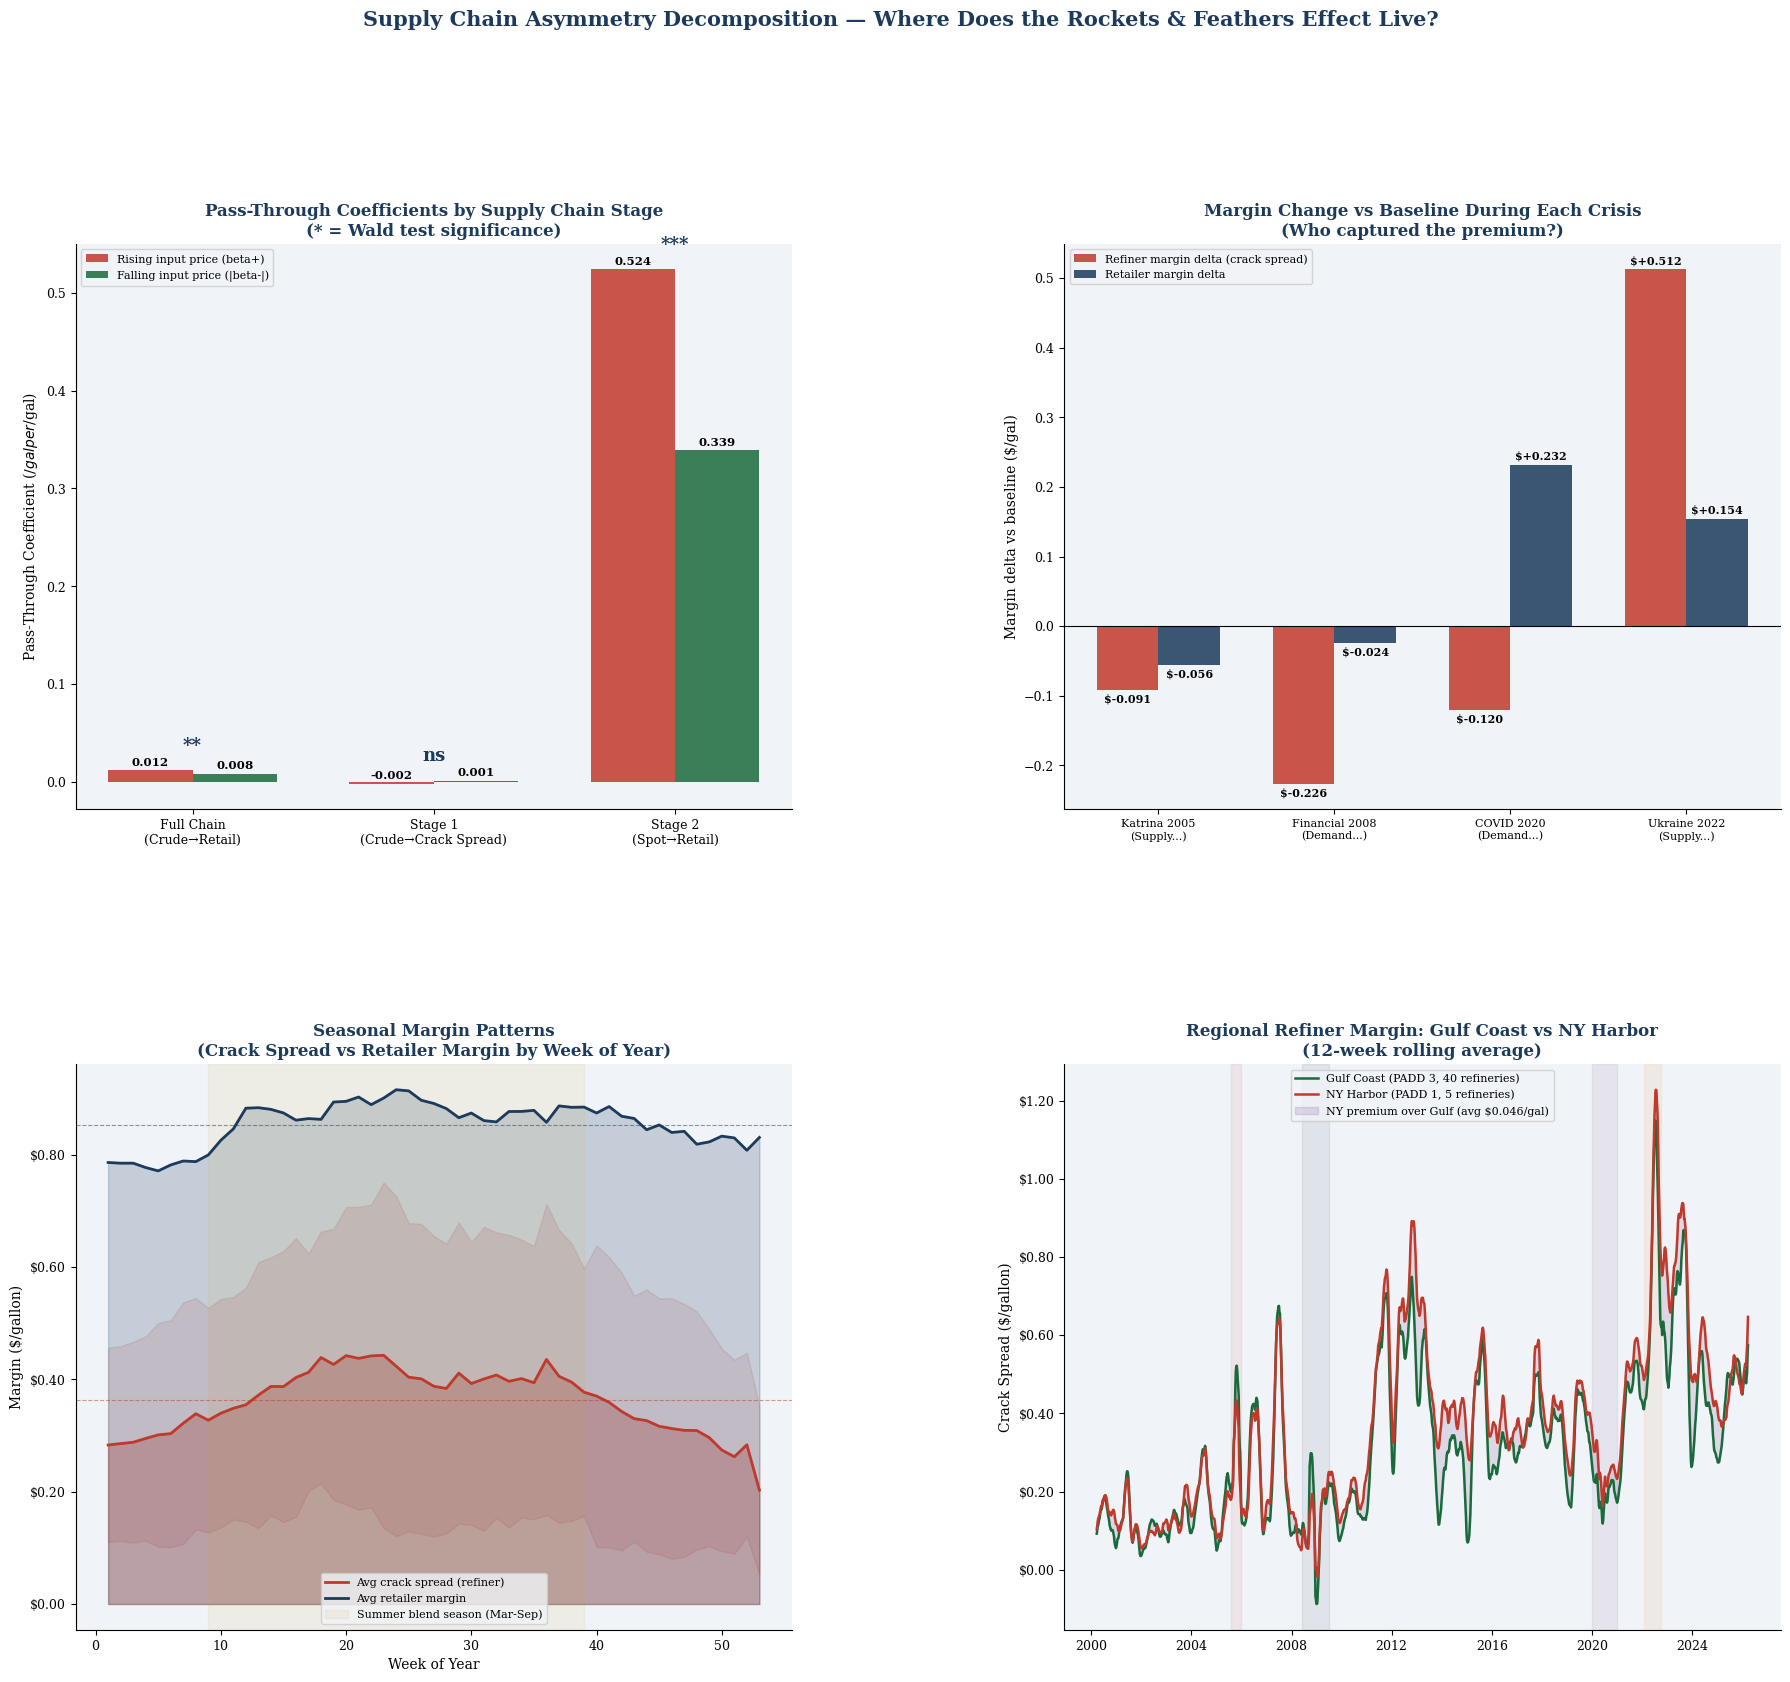

Saved: outputs/crack_asymmetry_decomposition.png


In [10]:
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

# ── Chart 1: Two-stage asymmetry comparison bar chart ────────────────────
ax1 = fig.add_subplot(gs[0, 0])

stages  = ['Full Chain\n(Crude→Retail)', 'Stage 1\n(Crude→Crack Spread)', 'Stage 2\n(Spot→Retail)']
b_pos   = [s0['beta_pos'], s1['beta_pos'], s2['beta_pos']]
b_neg   = [abs(s0['beta_neg']), abs(s1['beta_neg']), abs(s2['beta_neg'])]
w_ps    = [wp0, wp1, wp2]

x     = np.arange(len(stages))
width = 0.35
b1    = ax1.bar(x - width/2, b_pos, width, label='Rising input price (beta+)',
                color=RED, alpha=0.85)
b2    = ax1.bar(x + width/2, b_neg, width, label='Falling input price (|beta-|)',
                color=GREEN, alpha=0.85)

for bar, val in zip(list(b1)+list(b2), b_pos+b_neg):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Significance stars
for i, (wp, bpos, bneg) in enumerate(zip(w_ps, b_pos, b_neg)):
    star = '***' if wp<0.001 else '**' if wp<0.01 else '*' if wp<0.05 else 'ns'
    ymax = max(bpos, bneg) + 0.02
    ax1.text(x[i], ymax, star, ha='center', fontsize=13, color=NAVY, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(stages, fontsize=9)
ax1.set_title('Pass-Through Coefficients by Supply Chain Stage\n(* = Wald test significance)',
              fontweight='bold', color=NAVY)
ax1.set_ylabel('Pass-Through Coefficient ($/gal per $/gal)')
ax1.legend(fontsize=8)
ax1.set_facecolor(LGRAY)

# ── Chart 2: Crisis margin winner chart ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

crisis_names  = list(crisis_results.keys())
cs_deltas     = [crisis_results[n]['cs_delta'] for n in crisis_names]
rm_deltas     = [crisis_results[n]['rm_delta'] for n in crisis_names]
shock_types   = [crisis_results[n]['shock_type'] for n in crisis_names]

x2    = np.arange(len(crisis_names))
w2    = 0.35
bb1   = ax2.bar(x2 - w2/2, cs_deltas, w2, label='Refiner margin delta (crack spread)',
                color=RED, alpha=0.85)
bb2   = ax2.bar(x2 + w2/2, rm_deltas, w2, label='Retailer margin delta',
                color=NAVY, alpha=0.85)

for bar, val in zip(list(bb1)+list(bb2), cs_deltas+rm_deltas):
    va  = 'bottom' if val >= 0 else 'top'
    off = 0.005 if val >= 0 else -0.005
    ax2.text(bar.get_x()+bar.get_width()/2, val+off,
             f'${val:+.3f}', ha='center', va=va, fontsize=8, fontweight='bold')

ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x2)
ax2.set_xticklabels([f'{n}\n({t[:6]}...)' if len(t)>12 else f'{n}\n({t})'
                     for n, t in zip(crisis_names, shock_types)], fontsize=8)
ax2.set_title('Margin Change vs Baseline During Each Crisis\n(Who captured the premium?)',
              fontweight='bold', color=NAVY)
ax2.set_ylabel('Margin delta vs baseline ($/gal)')
ax2.legend(fontsize=8)
ax2.set_facecolor(LGRAY)

# ── Chart 3: Seasonal crack spread pattern ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.fill_between(seasonal['week_of_year'], seasonal['crack_mean'],
                 alpha=0.30, color=RED)
ax3.plot(seasonal['week_of_year'], seasonal['crack_mean'],
         color=RED, lw=2.0, label='Avg crack spread (refiner)')
ax3.fill_between(seasonal['week_of_year'],
                 seasonal['crack_mean'] - seasonal['crack_std'],
                 seasonal['crack_mean'] + seasonal['crack_std'],
                 alpha=0.12, color=RED)
ax3.fill_between(seasonal['week_of_year'], seasonal['retailer_mean'],
                 alpha=0.20, color=NAVY)
ax3.plot(seasonal['week_of_year'], seasonal['retailer_mean'],
         color=NAVY, lw=2.0, label='Avg retailer margin')
ax3.axvspan(9, 39, alpha=0.08, color=GOLD, label='Summer blend season (Mar-Sep)')
ax3.axhline(df['crack_spread'].mean(), color=RED, lw=0.8, ls='--', alpha=0.5)
ax3.axhline(df['retailer_margin'].mean(), color=NAVY, lw=0.8, ls='--', alpha=0.5)
ax3.set_title('Seasonal Margin Patterns\n(Crack Spread vs Retailer Margin by Week of Year)',
              fontweight='bold', color=NAVY)
ax3.set_xlabel('Week of Year')
ax3.set_ylabel('Margin ($/gallon)')
ax3.legend(fontsize=8)
ax3.set_facecolor(LGRAY)
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))

# ── Chart 4: Regional crack spread Gulf vs NYH ───────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['period'], df['crack_gulf'].rolling(12).mean(),
         color=GREEN, lw=1.8, label='Gulf Coast (PADD 3, 40 refineries)')
ax4.plot(df['period'], df['crack_nyh'].rolling(12).mean(),
         color=RED, lw=1.8, label='NY Harbor (PADD 1, 5 refineries)')
ax4.fill_between(df['period'],
                 df['crack_gulf'].rolling(12).mean(),
                 df['crack_nyh'].rolling(12).mean(),
                 alpha=0.15, color=PURPLE,
                 label=f'NY premium over Gulf (avg ${regional_gap:.3f}/gal)')
for _, (start, end, color) in CRISES.items():
    ax4.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color=color)

ax4.set_title('Regional Refiner Margin: Gulf Coast vs NY Harbor\n(12-week rolling average)',
              fontweight='bold', color=NAVY)
ax4.set_ylabel('Crack Spread ($/gallon)')
ax4.legend(fontsize=8)
ax4.set_facecolor(LGRAY)
ax4.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))

fig.suptitle(
    'Supply Chain Asymmetry Decomposition — Where Does the Rockets & Feathers Effect Live?',
    fontsize=15, fontweight='bold', color=NAVY, y=1.01
)

plt.savefig('outputs/crack_asymmetry_decomposition.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: outputs/crack_asymmetry_decomposition.png')

## 10. Summary Table (Poster-Ready PNG)

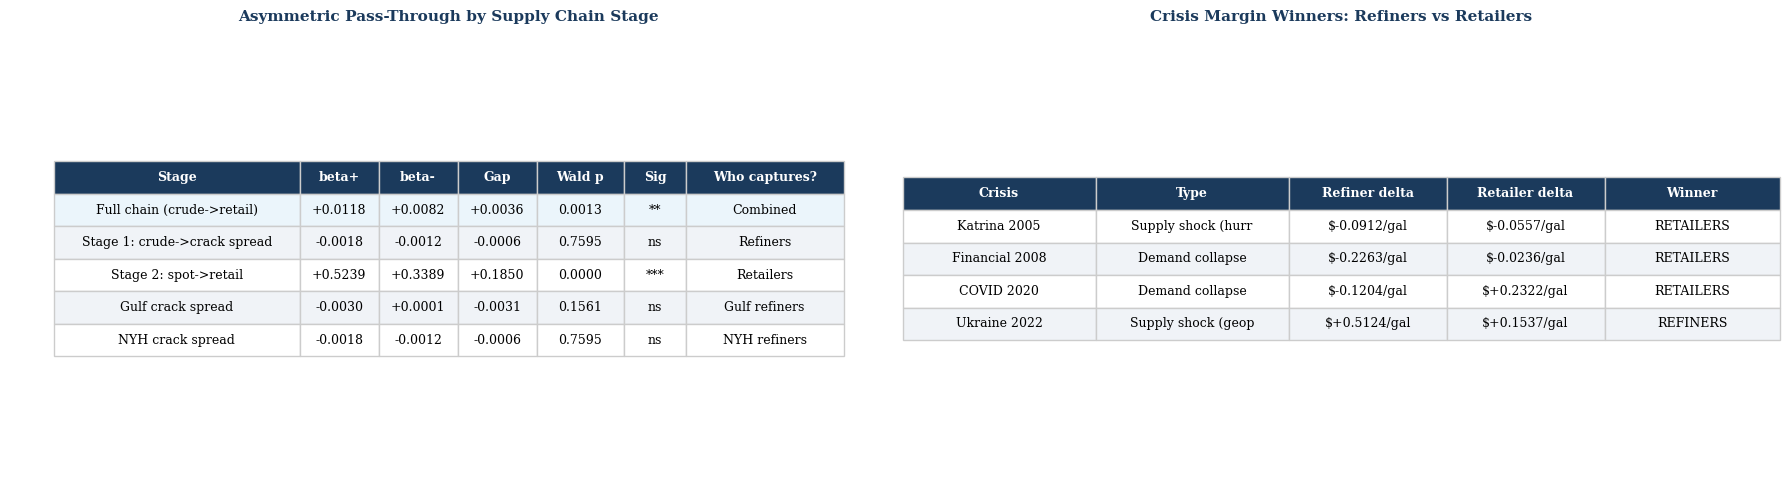

Saved: outputs/table_crack_summary.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.patch.set_facecolor('white')

# --- Table 1: Asymmetry by stage ---
ax = axes[0]
ax.set_facecolor('white')
ax.axis('off')

t1_data = [
    ['Stage', 'beta+', 'beta-', 'Gap', 'Wald p', 'Sig', 'Who captures?'],
    ['Full chain (crude->retail)',
     f'{s0["beta_pos"]:+.4f}', f'{s0["beta_neg"]:+.4f}',
     f'{s0["asym_gap"]:+.4f}', f'{wp0:.4f}', s0['wald_sig'], 'Combined'],
    ['Stage 1: crude->crack spread',
     f'{s1["beta_pos"]:+.4f}', f'{s1["beta_neg"]:+.4f}',
     f'{s1["asym_gap"]:+.4f}', f'{wp1:.4f}', s1['wald_sig'], 'Refiners'],
    ['Stage 2: spot->retail',
     f'{s2["beta_pos"]:+.4f}', f'{s2["beta_neg"]:+.4f}',
     f'{s2["asym_gap"]:+.4f}', f'{wp2:.4f}', s2['wald_sig'], 'Retailers'],
    ['Gulf crack spread',
     f'{s_gulf["beta_pos"]:+.4f}', f'{s_gulf["beta_neg"]:+.4f}',
     f'{s_gulf["asym_gap"]:+.4f}', f'{wp_gulf:.4f}', s_gulf['wald_sig'], 'Gulf refiners'],
    ['NYH crack spread',
     f'{s_nyh["beta_pos"]:+.4f}', f'{s_nyh["beta_neg"]:+.4f}',
     f'{s_nyh["asym_gap"]:+.4f}', f'{wp_nyh:.4f}', s_nyh['wald_sig'], 'NYH refiners'],
]

tbl = ax.table(cellText=t1_data[1:], colLabels=t1_data[0],
               cellLoc='center', loc='center',
               colWidths=[0.28, 0.09, 0.09, 0.09, 0.10, 0.07, 0.18])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.7)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r == 0:
        cell.set_facecolor(NAVY)
        cell.set_text_props(color='white', fontweight='bold')
    elif r == 1:
        cell.set_facecolor('#EBF5FB')
    elif r % 2 == 0:
        cell.set_facecolor(LGRAY)
    else:
        cell.set_facecolor('white')

ax.set_title('Asymmetric Pass-Through by Supply Chain Stage',
             fontsize=11, fontweight='bold', color=NAVY, pad=12)

# --- Table 2: Crisis margin winners ---
ax2 = axes[1]
ax2.set_facecolor('white')
ax2.axis('off')

t2_data = [
    ['Crisis', 'Type', 'Refiner delta', 'Retailer delta', 'Winner'],
]
for name, res in crisis_results.items():
    t2_data.append([
        name, res['shock_type'][:18],
        f'${res["cs_delta"]:+.4f}/gal',
        f'${res["rm_delta"]:+.4f}/gal',
        res['winner']
    ])

tbl2 = ax2.table(cellText=t2_data[1:], colLabels=t2_data[0],
                 cellLoc='center', loc='center',
                 colWidths=[0.22, 0.22, 0.18, 0.18, 0.20])
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)
tbl2.scale(1, 1.7)
for (r, c), cell in tbl2.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r == 0:
        cell.set_facecolor(NAVY)
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor(LGRAY)
    else:
        cell.set_facecolor('white')

ax2.set_title('Crisis Margin Winners: Refiners vs Retailers',
              fontsize=11, fontweight='bold', color=NAVY, pad=12)

plt.tight_layout()
plt.savefig('outputs/table_crack_summary.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: outputs/table_crack_summary.png')

## 11. Full Results Summary

In [12]:
print('='*70)
print('  NOTEBOOK 09 — CRACK SPREAD MEDIATION: FULL RESULTS')
print('='*70)

print(f'''
PUMP PRICE DECOMPOSITION (26-year average)
  Crude cost       : ${df.crude_per_gallon.mean():.4f}/gal  ({df.crude_per_gallon.mean()/df.retail_national.mean()*100:.1f}%)
  Refiner margin   : ${df.crack_spread.mean():.4f}/gal  ({df.crack_spread.mean()/df.retail_national.mean()*100:.1f}%)
  Retailer margin  : ${df.retailer_margin.mean():.4f}/gal  ({df.retailer_margin.mean()/df.retail_national.mean()*100:.1f}%)
  Total pump price : ${df.retail_national.mean():.4f}/gal  (100%)

ASYMMETRY BY STAGE
  Full chain (crude->retail) : gap={s0['asym_gap']:+.4f}  Wald p={wp0:.4f}  {s0['wald_sig']}
  Stage 1 (crude->crack)     : gap={s1['asym_gap']:+.4f}  Wald p={wp1:.4f}  {s1['wald_sig']}
  Stage 2 (spot->retail)     : gap={s2['asym_gap']:+.4f}  Wald p={wp2:.4f}  {s2['wald_sig']}

CRISIS MARGIN WINNERS
  Supply shocks (Katrina, Ukraine) -> {crisis_results['Ukraine 2022']['winner']} captured premium
  Demand collapse (COVID, 2008)    -> {crisis_results['COVID 2020']['winner']} captured premium
  Ukraine 2022: crack spread peaked at ${crisis_results['Ukraine 2022']['cs_max']:.4f}/gal (record high)

SEASONALITY
  Summer blend premium on crack spread: ${summer_premium:.4f}/gal

REGIONAL
  NYH crack spread premium over Gulf: ${regional_gap:.4f}/gal
  (Fewer refineries in PADD 1 -> less competition -> higher refiner margin)

OUTPUTS
  outputs/crack_margin_history.png
  outputs/crack_asymmetry_decomposition.png
  outputs/table_crack_summary.png
''')

  NOTEBOOK 09 — CRACK SPREAD MEDIATION: FULL RESULTS

PUMP PRICE DECOMPOSITION (26-year average)
  Crude cost       : $1.5186/gal  (55.5%)
  Refiner margin   : $0.3624/gal  (13.3%)
  Retailer margin  : $0.8537/gal  (31.2%)
  Total pump price : $2.7347/gal  (100%)

ASYMMETRY BY STAGE
  Full chain (crude->retail) : gap=+0.0036  Wald p=0.0013  **
  Stage 1 (crude->crack)     : gap=-0.0006  Wald p=0.7595  ns
  Stage 2 (spot->retail)     : gap=+0.1850  Wald p=0.0000  ***

CRISIS MARGIN WINNERS
  Supply shocks (Katrina, Ukraine) -> REFINERS captured premium
  Demand collapse (COVID, 2008)    -> RETAILERS captured premium
  Ukraine 2022: crack spread peaked at $1.5653/gal (record high)

SEASONALITY
  Summer blend premium on crack spread: $0.0886/gal

REGIONAL
  NYH crack spread premium over Gulf: $0.0465/gal
  (Fewer refineries in PADD 1 -> less competition -> higher refiner margin)

OUTPUTS
  outputs/crack_margin_history.png
  outputs/crack_asymmetry_decomposition.png
  outputs/table_crack_s